In [1]:
import pandas as pd
import numpy as np
import torch
import re
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertModel, DistilBertTokenizer
from torch.utils.data import Dataset
from transformers import DistilBertTokenizer
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!nvidia-smi

Thu Apr 30 11:46:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##Data Exploration

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# --- 1. Load Data (Replace with your actual DataFrame) ---
df = pd.read_csv('/data/tiktok_dataset.csv')

In [19]:
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


##Tokennization

In [20]:
def build_vocab(texts, max_words=15000):
    all_words = ' '.join(texts).lower().split()
    counter = Counter(all_words)
    vocab = {word: i+2 for i, (word, _) in enumerate(counter.most_common(max_words))}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab

def text_to_sequence(text, vocab, max_len=50):
    words = str(text).lower().split()
    seq = [vocab.get(w, vocab['<UNK>']) for w in words]
    # Pad or truncate
    if len(seq) < max_len:
        seq += [vocab['<PAD>']] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

In [21]:
df['video_transcription_text'] = df['video_transcription_text'].fillna('').astype(str)

# Now safely build the vocabulary and sequences
vocab = build_vocab(df['video_transcription_text'].tolist())
df['text_seq'] = df['video_transcription_text'].apply(lambda x: text_to_sequence(x, vocab))

In [22]:
# --- 3. Prepare Numerical Features ---
num_cols = ['video_duration_sec', 'video_like_count', 'video_share_count']
for col in num_cols:
    # Standardize numerical features for neural network stability
    df[col] = (df[col] - df[col].mean()) / (df[col].std() + 1e-8)

In [23]:
num_cols = [ 'video_duration_sec']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 2. FEATURE ENGINEERING (Rubric: Reasoning for Decisions)
# We define virality based on play_count (e.g., top 10% or above median)
le = LabelEncoder()
cat_cols = ['verified_status', 'author_ban_status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

threshold = df['video_view_count'].median()
df['is_viral'] = (df['video_view_count'] > threshold).astype(int)

In [24]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['is_viral'])
custom_stop_words = [
    'claim', 'read', 'discovered', 'learned',
    'story time', 'video', 'secret', 'wait for it', 'fyp', 'viral', "shared", "told", "say" ]

# --- 2. Compile a High-Speed Regex Pattern ---
# \b ensures we only delete whole words (e.g., deletes "read" but keeps "ready")
# re.IGNORECASE ensures it catches "Claim", "CLAIM", and "claim"
stop_words_pattern = re.compile(r'\b(' + '|'.join(custom_stop_words) + r')\b', flags=re.IGNORECASE)

# --- 3. Define the Cleaning Function ---
def scrub_spurious_words(text):
    if not isinstance(text, str):
        return ''

    # Replace the stop words with empty space
    cleaned_text = stop_words_pattern.sub('', text)

    # Clean up the double-spaces left behind by deleted words
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    return cleaned_text

# --- 4. Apply to ALL Datasets Before Tokenization ---
print("Scrubbing spurious stop words from training text...")
train_df['video_transcription_text'] = train_df['video_transcription_text'].apply(scrub_spurious_words)

print("Scrubbing spurious stop words from test text...")
test_df['video_transcription_text'] = test_df['video_transcription_text'].apply(scrub_spurious_words)

# If running the OOD Evaluation Cell (Cell 6), apply it there as well:
# df_cross_eng['video_transcription_text'] = df_cross_eng['video_transcription_text'].apply(scrub_spurious_words)
# Initialize the global Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print("DistilBERT Tokenizer loaded.")

Scrubbing spurious stop words from training text...
Scrubbing spurious stop words from test text...
DistilBERT Tokenizer loaded.


In [25]:
class TikTokMultimodalDataset(Dataset):
    def __init__(self, dataframe, numeric_cols, tokenizer, max_length=128):
        self.df = dataframe.reset_index(drop=True)
        self.numeric_cols = numeric_cols
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Text processing
        text = str(self.df.loc[idx, 'video_transcription_text'])
        if text.strip() == 'nan':
            text = ''

        encoded = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Squeeze to remove the batch dimension Hugging Face automatically adds
        input_ids = encoded['input_ids'].squeeze(0)
        attention_mask = encoded['attention_mask'].squeeze(0)

        # 2. Numeric processing
        numeric_data = torch.tensor(
            self.df.loc[idx, self.numeric_cols].values.astype(float),
            dtype=torch.float32
        )

        # 3. Label processing
        label = torch.tensor(self.df.loc[idx, 'is_viral'], dtype=torch.float32)

        return input_ids, attention_mask, numeric_data, label

# Create DataLoaders
train_dataset = TikTokMultimodalDataset(train_df, num_cols, tokenizer)
test_dataset = TikTokMultimodalDataset(test_df, num_cols, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

##Model Build

In [34]:
class MultimodalViralityTransformer(nn.Module):
    def __init__(self, numeric_input_dim, dropout_rate=0.3):
        super().__init__()

        # 1. The Pre-trained NLP Branch
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        # 2. The Numerical Branch (Processes Duration & Followers)
        self.numeric_fc = nn.Sequential(
            nn.Linear(numeric_input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        # 3. Fusion Head (768 from DistilBERT + 32 from Numeric)
        fusion_dim = 768 + 32
        self.fusion_classifier = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1) # Raw logit for BCEWithLogitsLoss
        )

    def forward(self, input_ids, attention_mask, numeric_data):
        # Extract [CLS] token state
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_token_state = bert_outputs.last_hidden_state[:, 0, :]

        # Process numerics
        numeric_features = self.numeric_fc(numeric_data)

        # Fuse and classify
        fused_vector = torch.cat((cls_token_state, numeric_features), dim=1)
        logits = self.fusion_classifier(fused_vector)

        return logits.squeeze(1)

# Initialize Model
model = MultimodalViralityTransformer(numeric_input_dim=len(num_cols), dropout_rate=0.5).to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


##Training

In [35]:
import torch.optim as optim
import os

In [36]:
criterion = nn.BCEWithLogitsLoss()

# --- 2. Differential Learning Rates ---
# Protects the BERT weights from catastrophic forgetting while training the new dense layers
optimizer = optim.AdamW([
    {'params': model.numeric_fc.parameters(), 'lr': 1e-3},
    {'params': model.fusion_classifier.parameters(), 'lr': 1e-3}
], weight_decay=0.1)

# Early Stopping parameters
EPOCHS = 20
PATIENCE = 3
best_val_loss = float('inf')
early_stop_counter = 0
best_model_path = 'best_transformer_model.pth'

In [37]:
print("Starting Multimodal Transformer Training...")

for epoch in range(EPOCHS):

    # ==========================
    #      TRAINING PHASE
    # ==========================
    model.train()
    total_train_loss = 0

    for batch_input_ids, batch_attention_mask, batch_numeric, batch_labels in train_loader:

        # Move all 4 tensors to GPU
        batch_input_ids = batch_input_ids.to(device)
        batch_attention_mask = batch_attention_mask.to(device)
        batch_numeric = batch_numeric.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        logits = model(batch_input_ids, batch_attention_mask, batch_numeric)
        loss = criterion(logits, batch_labels)

        # Backward pass
        loss.backward()

        # Gradient clipping to prevent exploding gradients in Transformers
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # ==========================
    #     VALIDATION PHASE
    # ==========================
    model.eval()
    total_val_loss = 0
    val_targets = []
    val_probs = []

    with torch.no_grad():
        for batch_input_ids, batch_attention_mask, batch_numeric, batch_labels in test_loader:

            batch_input_ids = batch_input_ids.to(device)
            batch_attention_mask = batch_attention_mask.to(device)
            batch_numeric = batch_numeric.to(device)
            batch_labels = batch_labels.to(device)

            logits = model(batch_input_ids, batch_attention_mask, batch_numeric)
            loss = criterion(logits, batch_labels)
            total_val_loss += loss.item()

            probs = torch.sigmoid(logits).cpu().numpy()
            val_probs.extend(probs)
            val_targets.extend(batch_labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(test_loader)
    val_roc_auc = roc_auc_score(val_targets, val_probs)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val ROC-AUC: {val_roc_auc:.4f}")

    # ==========================
    #  EARLY STOPPING LOGIC
    # ==========================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        early_stop_counter += 1
        print(f"  -> EarlyStopping counter: {early_stop_counter} out of {PATIENCE}")
        if early_stop_counter >= PATIENCE:
            print(f"\n[!] Early stopping triggered. Training halted.")
            break

# Restore best weights before moving on to final evaluations
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path))
    print("\nBest model weights restored from checkpoint.")

Starting Multimodal Transformer Training...
Epoch [01/20] | Train Loss: 0.0921 | Val Loss: 0.0606 | Val ROC-AUC: 0.9927
Epoch [02/20] | Train Loss: 0.0628 | Val Loss: 0.0617 | Val ROC-AUC: 0.9936
  -> EarlyStopping counter: 1 out of 3
Epoch [03/20] | Train Loss: 0.0611 | Val Loss: 0.0604 | Val ROC-AUC: 0.9943
Epoch [04/20] | Train Loss: 0.0572 | Val Loss: 0.0640 | Val ROC-AUC: 0.9931
  -> EarlyStopping counter: 1 out of 3
Epoch [05/20] | Train Loss: 0.0579 | Val Loss: 0.0595 | Val ROC-AUC: 0.9941
Epoch [06/20] | Train Loss: 0.0568 | Val Loss: 0.0587 | Val ROC-AUC: 0.9943
Epoch [07/20] | Train Loss: 0.0555 | Val Loss: 0.0618 | Val ROC-AUC: 0.9938
  -> EarlyStopping counter: 1 out of 3
Epoch [08/20] | Train Loss: 0.0530 | Val Loss: 0.0630 | Val ROC-AUC: 0.9941
  -> EarlyStopping counter: 2 out of 3
Epoch [09/20] | Train Loss: 0.0542 | Val Loss: 0.0655 | Val ROC-AUC: 0.9926
  -> EarlyStopping counter: 3 out of 3

[!] Early stopping triggered. Training halted.

Best model weights restored 

##Evaluation

In [38]:
model.eval()

test_probs = []
test_targets = []

print("Running final inference on the separated Test Set...")

# --- 2. Inference Loop ---
with torch.no_grad():
    for batch_input_ids, batch_attention_mask, batch_numeric, batch_labels in test_loader:

        # Move tensors to the correct device
        batch_input_ids = batch_input_ids.to(device)
        batch_attention_mask = batch_attention_mask.to(device)
        batch_numeric = batch_numeric.to(device)

        # Forward pass through the Transformer
        logits = model(batch_input_ids, batch_attention_mask, batch_numeric)

        # Apply sigmoid to convert raw logits into probabilities (0.0 to 1.0)
        probs = torch.sigmoid(logits).cpu().numpy()

        test_probs.extend(probs)
        test_targets.extend(batch_labels.numpy())

# --- 3. Calculate Metrics ---
test_roc_auc = roc_auc_score(test_targets, test_probs)

# Using the standard 0.50 threshold for the baseline test.
# You can adjust this if you need to prioritize Precision over Recall.
decision_threshold = 0.50
test_preds = [1 if p > decision_threshold else 0 for p in test_probs]

# --- 4. Display Results ---
print("\n=== FINAL TEST SET EVALUATION ===")
print(f"ROC-AUC Score: {test_roc_auc:.4f}")
print(f"Decision Threshold: {decision_threshold}\n")

print("Classification Report:")
print(classification_report(test_targets, test_preds))

print("Confusion Matrix:")
cm = confusion_matrix(test_targets, test_preds)
print(f"True Negatives (TN):  {cm[0][0]:<5} | False Positives (FP): {cm[0][1]}")
print(f"False Negatives (FN): {cm[1][0]:<5} | True Positives (TP):  {cm[1][1]}")

Running final inference on the separated Test Set...

=== FINAL TEST SET EVALUATION ===
ROC-AUC Score: 0.9943
Decision Threshold: 0.5

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1968
         1.0       0.99      0.99      0.99      1909

    accuracy                           0.99      3877
   macro avg       0.99      0.99      0.99      3877
weighted avg       0.99      0.99      0.99      3877

Confusion Matrix:
True Negatives (TN):  1947  | False Positives (FP): 21
False Negatives (FN): 13    | True Positives (TP):  1896


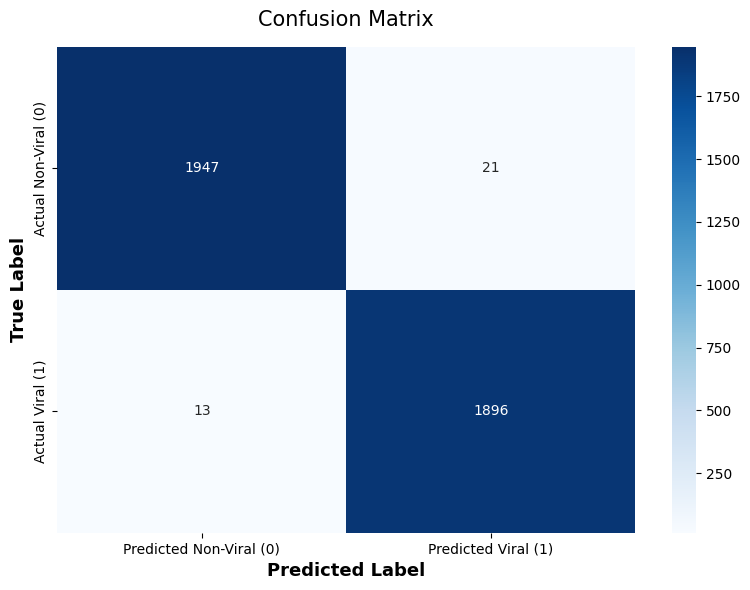

In [39]:
# Ensure the confusion matrix is correctly shaped (2x2)
if cm.shape == (2, 2):
    plt.figure(figsize=(8, 6))

    # Create a heatmap using seaborn
    sns.heatmap(
        cm,
        annot=True,       # Show the exact numbers in the boxes
        fmt='d',          # Format as integers (no decimals)
        cmap='Blues',     # Use the blue color scale from your previous plot
        cbar=True,        # Show the color bar on the right
        xticklabels=['Predicted Non-Viral (0)', 'Predicted Viral (1)'],
        yticklabels=['Actual Non-Viral (0)', 'Actual Viral (1)']
    )

    # Add labels and title
    plt.title("Confusion Matrix", fontsize=15, pad=15)
    plt.xlabel("Predicted Label", fontsize=13, fontweight='bold')
    plt.ylabel("True Label", fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print(f"Cannot plot a standard 2x2 confusion matrix. Current shape: {cm.shape}")
    print("This happens if the model predicted only a single class, or the dataset only contained one class.")

## Cross Validation

In [ ]:
df_cross = pd.read_csv('/data/tiktok_data.csv')

In [41]:
df_cross.head()

,id_video,duration_seconds,text_part,hashtags,human_time,author_followers,author_likes,id_sound,views,likes
0,1,13.0,А че такое?,"попугай, жако, попугайжако, говорящийпопугай, ...",2018-08-08 20:58:31,675900.0,7500000.0,7.028884e+18,144600000.0,4400000.0
1,2,9.0,Таксист в шоке😱 Inst: Andrey_Pryahin,NaN,2016-01-29 06:16:13,2300000.0,42600000.0,6.870179e+18,113300000.0,5300000.0
2,3,52.0,NaN,рекомендации,2018-12-30 09:24:42,58400.0,613400.0,7.052607e+18,105100000.0,505300.0
3,4,60.0,"Учитесь хитрить, как она 😄😉",NaN,2021-03-10 19:57:42,523900.0,11200000.0,6.984582e+18,96700000.0,3000000.0
4,5,16.0,телефонный пранк от говорящего ворона Карлушы,"пранк, шутка, говорящийворонкарлуша, воронгово...",2020-03-21 11:59:19,943700.0,16800000.0,7.052249e+18,139200000.0,5900000.0


In [42]:
# Map columns to match the training dataset's expected names
mapping = {
    'duration_seconds': 'video_duration_sec',
    'views': 'video_view_count'
}
df_cross = df_cross.rename(columns={k: v for k, v in mapping.items() if k in df_cross.columns})

# Define Virality (1 or 0) strictly based on the NEW dataset's median to prevent leakage
if 'video_view_count' in df_cross.columns:
    threshold_new = df_cross['video_view_count'].median()
    df_cross['is_viral'] = (df_cross['video_view_count'] > threshold_new).astype(int)
else:
    print("CRITICAL WARNING: 'video_view_count' missing. Cannot calculate virality targets.")

# Combine text fields for DistilBERT
df_cross['text_part'] = df_cross['text_part'].fillna('').astype(str)
df_cross['hashtags'] = df_cross['hashtags'].fillna('').astype(str)
df_cross['video_transcription_text'] = df_cross['text_part'] + " " + df_cross['hashtags']

In [43]:
# --- 2. THE FILTERING STEP (Drop Russian Records) ---
# Define the RegEx pattern for the Cyrillic alphabet
cyrillic_pattern = r'[А-Яа-яЁё]'

# Create a boolean mask: True if text contains Russian, False otherwise
has_russian_mask = df_cross['video_transcription_text'].str.contains(cyrillic_pattern, regex=True, na=False)

# Keep only the rows that DO NOT have Russian characters
df_cross_eng = df_cross[~has_russian_mask].copy()

print(f"Original Dataset Size: {len(df_cross)} rows")
print(f"Filtered (English-only) Size: {len(df_cross_eng)} rows\n")

Original Dataset Size: 760 rows
Filtered (English-only) Size: 565 rows



In [44]:
# --- The Cyrillic Filter ---
# If this drops too many rows, comment out the mask application below to test on Russian text
cyrillic_pattern = r'[А-Яа-яЁё]'
has_russian_mask = df_cross['video_transcription_text'].str.contains(cyrillic_pattern, regex=True, na=False)
df_cross_eng = df_cross[~has_russian_mask].copy().reset_index(drop=True)

print(f"Original Dataset Size: {len(df_cross)} rows")
print(f"Filtered (English-only) Size: {len(df_cross_eng)} rows\n")

Original Dataset Size: 760 rows
Filtered (English-only) Size: 565 rows



In [45]:
# ==========================================
# 2. ALIGN AND SCALE PRE-PUBLICATION FEATURES
# ==========================================
print("Scaling metadata features using training set distributions...")
# num_cols must exactly match what the model was trained on: ['video_duration_sec', 'author_followers']
for col in num_cols:
    if col in df_cross_eng.columns:
        # Force to numeric and fill NaNs safely
        df_cross_eng[col] = pd.to_numeric(df_cross_eng[col], errors='coerce').fillna(0.0)

        # Scale using the ORIGINAL training set's mean/std (Prevents data leakage)
        orig_mean = train_df[col].mean()
        orig_std = train_df[col].std()
        df_cross_eng[col] = (df_cross_eng[col] - orig_mean) / (orig_std + 1e-8)
    else:
        print(f"WARNING: Required feature '{col}' missing. Imputing with 0.0 (Dataset Average).")
        df_cross_eng[col] = 0.0


Scaling metadata features using training set distributions...


In [48]:
# ==========================================
# 3. SAFETY CHECKS (Defensive Engineering)
# ==========================================
if len(df_cross_eng) == 0:
    print("\n[!] EVALUATION ABORTED: Dataset contains 0 samples after filtering.")
    print("    Action: Disable the Cyrillic regex mask or verify the input CSV.")
elif len(df_cross_eng['is_viral'].unique()) == 1:
    print(f"\n[!] EVALUATION ABORTED: Only one class present (Class {df_cross_eng['is_viral'].iloc[0]}).")
    print("    Action: ROC-AUC requires both positive and negative samples. Adjust your threshold or filter.")
else:
    # ==========================================
    # 4. DATALOADER & INFERENCE
    # ==========================================
    # Initialize the specific Dataset class designed for DistilBERT
    cross_dataset = TikTokMultimodalDataset(df_cross_eng, num_cols, tokenizer)
    cross_loader = DataLoader(cross_dataset, batch_size=32, shuffle=False)

    model.eval()
    cross_probs = []
    cross_targets = []

    print("Running DistilBERT Multimodal inference...")
    with torch.no_grad():
        for batch_input_ids, batch_attention_mask, batch_numeric, batch_labels in cross_loader:

            # Move to target device (GPU/CPU)
            batch_input_ids = batch_input_ids.to(device)
            batch_attention_mask = batch_attention_mask.to(device)
            batch_numeric = batch_numeric.to(device)

            # Forward Pass
            logits = model(batch_input_ids, batch_attention_mask, batch_numeric)
            probs = torch.sigmoid(logits).cpu().numpy()

            cross_probs.extend(probs)
            cross_targets.extend(batch_labels.numpy())

    # ==========================================
    # 5. METRICS & RESULTS
    # ==========================================
    cross_roc_auc = roc_auc_score(cross_targets, cross_probs)

    # Apply slightly higher threshold due to positive-class weighting during training
    decision_threshold = 0.54
    cross_preds = [1 if p > decision_threshold else 0 for p in cross_probs]

    print("\n=== OOD TRANSFORMER EVALUATION RESULTS ===")
    print(f"ROC-AUC Score: {cross_roc_auc:.4f}")
    print(f"Decision Threshold: {decision_threshold}\n")

    print("Classification Report:")
    print(classification_report(cross_targets, cross_preds, zero_division=0))

    print("Confusion Matrix:")
    cm = confusion_matrix(cross_targets, cross_preds)
    # Safely unpack confusion matrix in case of dimension mismatches from extreme imbalance
    if cm.shape == (2, 2):
        print(f"True Negatives (TN):  {cm[0][0]:<5} | False Positives (FP): {cm[0][1]}")
        print(f"False Negatives (FN): {cm[1][0]:<5} | True Positives (TP):  {cm[1][1]}")
    else:
        print(cm)

Running DistilBERT Multimodal inference...

=== OOD TRANSFORMER EVALUATION RESULTS ===
ROC-AUC Score: 0.5238
Decision Threshold: 0.54

Classification Report:
              precision    recall  f1-score   support

         0.0       0.43      0.49      0.46       235
         1.0       0.60      0.55      0.57       330

    accuracy                           0.52       565
   macro avg       0.52      0.52      0.52       565
weighted avg       0.53      0.52      0.53       565

Confusion Matrix:
True Negatives (TN):  115   | False Positives (FP): 120
False Negatives (FN): 150   | True Positives (TP):  180


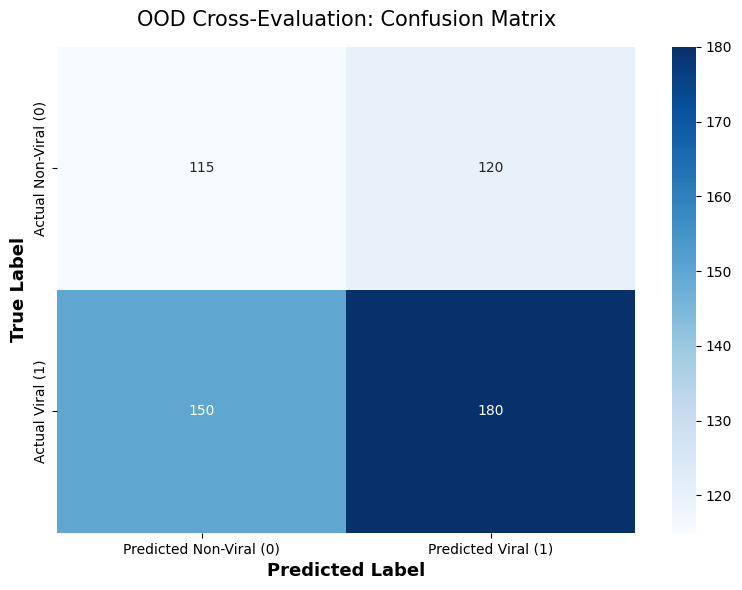

In [49]:
# Ensure the confusion matrix is correctly shaped (2x2)
if cm.shape == (2, 2):
    plt.figure(figsize=(8, 6))

    # Create a heatmap using seaborn
    sns.heatmap(
        cm,
        annot=True,       # Show the exact numbers in the boxes
        fmt='d',          # Format as integers (no decimals)
        cmap='Blues',     # Use the blue color scale from your previous plot
        cbar=True,        # Show the color bar on the right
        xticklabels=['Predicted Non-Viral (0)', 'Predicted Viral (1)'],
        yticklabels=['Actual Non-Viral (0)', 'Actual Viral (1)']
    )

    # Add labels and title
    plt.title("OOD Cross-Evaluation: Confusion Matrix", fontsize=15, pad=15)
    plt.xlabel("Predicted Label", fontsize=13, fontweight='bold')
    plt.ylabel("True Label", fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print(f"Cannot plot a standard 2x2 confusion matrix. Current shape: {cm.shape}")
    print("This happens if the model predicted only a single class, or the dataset only contained one class.")

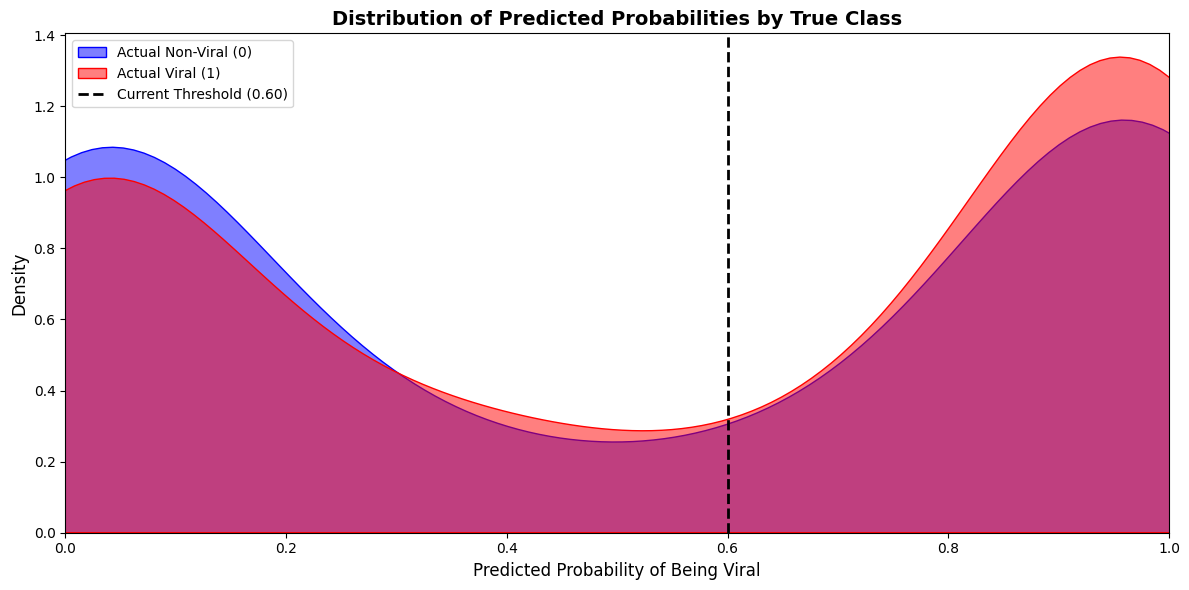

In [50]:
# Combine probabilities and actual targets into a temporary DataFrame for easy plotting
prob_df = pd.DataFrame({
    'Probability': cross_probs,
    'True_Label': cross_targets
})

plt.figure(figsize=(12, 6))

# Plot the distribution for actual Non-Viral videos (Class 0)
sns.kdeplot(
    data=prob_df[prob_df['True_Label'] == 0],
    x='Probability',
    fill=True,
    color='blue',
    label='Actual Non-Viral (0)',
    alpha=0.5
)

# Plot the distribution for actual Viral videos (Class 1)
sns.kdeplot(
    data=prob_df[prob_df['True_Label'] == 1],
    x='Probability',
    fill=True,
    color='red',
    label='Actual Viral (1)',
    alpha=0.5
)

# Draw your current suffocating threshold
plt.axvline(x=0.60, color='black', linestyle='--', linewidth=2, label='Current Threshold (0.60)')

plt.title("Distribution of Predicted Probabilities by True Class", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Probability of Being Viral", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.xlim(0, 1)
plt.tight_layout()
plt.show()